In [51]:
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch, timm
import shutil
import torchvision.transforms as T
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import numpy as np

In [37]:
# ----- Create Dataset -----

INPUT_FOLDER = Path("../data/raw/Preston Montford 2026")
OUTPUT_FOLDER = Path("../data/reid_data")

OUTPUT_FOLDER.mkdir(exist_ok=True)

selected = {}

for img_path in INPUT_FOLDER.rglob("*.jpg"):

    # Split filename into parts using "_" and "-"
    parts = img_path.stem.replace("-", "_").split("_")

    identity = None

    for part in parts:
        part = part.upper()

        if part.startswith("GCN"):
            identity = part
            break

    if identity is None:
        continue

    # Keep only first image for each identity
    if identity not in selected:
        selected[identity] = img_path

# Copy selected images
for img_path in selected.values():
    shutil.copy2(img_path, OUTPUT_FOLDER / img_path.name)

print(f"Copied {len(selected)} images.")

Copied 12 images.


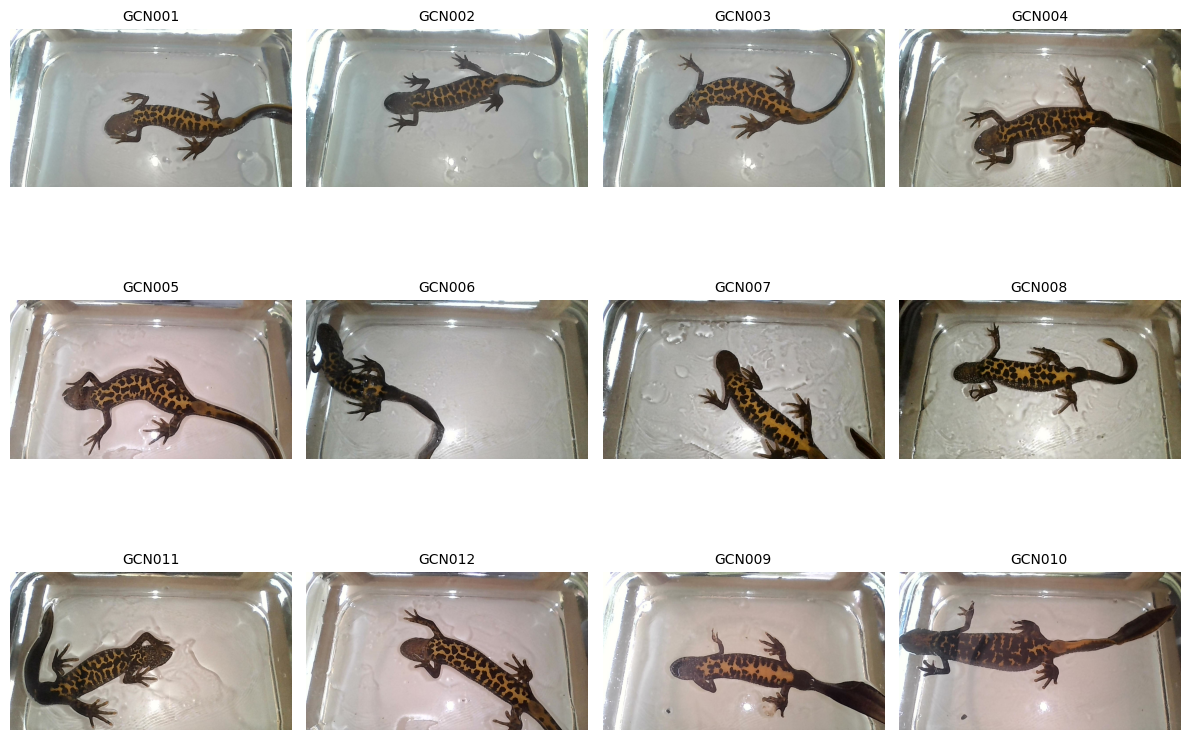

In [8]:
# ----- Plot Dataset -----

images = sorted(OUTPUT_FOLDER.glob("*.jpg"))

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

for ax, img_path in zip(axes, images):

    img = Image.open(img_path)

    # identity assumed to be first token containing GCN
    identity = next(
        (part for part in img_path.stem.replace("-", "_").split("_")
         if part.upper().startswith("GCN")),
        img_path.stem
    )

    ax.imshow(img)
    ax.set_title(identity, fontsize=10)
    ax.axis("off")

# hide unused axes if fewer than 12 images
for ax in axes[len(images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [43]:
# ----- split into gallery and queries -----

imgs = defaultdict(list) 

for f in OUTPUT_FOLDER.glob("*.jpg"):
    animal_id = f.stem.split("-")[2]  # GCN001
    imgs[animal_id].append(f)

gallery = {k: v[0] for k, v in imgs.items()}

In [57]:
# ----- MegaDescriptor -----

model = timm.create_model(
    "hf-hub:BVRA/MegaDescriptor-L-384",
    pretrained=True
).eval()

tfm = T.Compose([
    T.Resize((384, 384)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

def embed(img_file):
    img = Image.open(img_file).convert("RGB")
    with torch.no_grad():
        return model(tfm(img).unsqueeze(0)).squeeze().numpy()

# ----- embeddings -----

gallery_ids = list(gallery.keys())
gallery_emb = np.vstack([embed(f) for f in gallery.values()])

In [ ]:
# ----- similarity matrix -----

sim = cosine_similarity(gallery_emb, gallery_emb)
print("Similarity matrix shape:", sim.shape)

Similarity matrix shape: (12, 12)


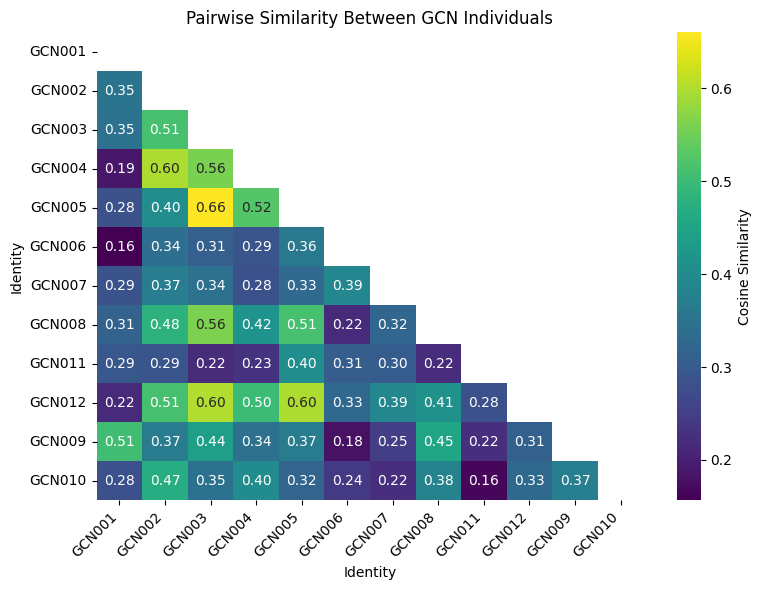

In [59]:
labels = list(imgs.keys())

plt.figure(figsize=(8, 6))

mask = np.triu(np.ones_like(sim, dtype=bool), k=0)

sns.heatmap(
    sim,
    mask=mask,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={"label": "Cosine Similarity"}
)

plt.title("Pairwise Similarity Between GCN Individuals")
plt.xlabel("Identity")
plt.ylabel("Identity")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [60]:
# ----- nearest neighbour re-id -----

# set diagonal to zero
sim_no_diag = sim.copy()
np.fill_diagonal(sim_no_diag, 0)

pred_idx = sim_no_diag.argmax(axis=1)
pred_ids = [gallery_ids[i] for i in pred_idx]

# ----- accuracy -----

acc = np.mean(np.array(pred_ids) == np.array(gallery_ids))
print(f"Top-1 Accuracy = {acc:.3f}")

# ----- inspect matches -----

for true_id, pred_id, score in zip(
        gallery_ids,
        pred_ids,
        sim_no_diag.max(axis=1)):
    print(f"True={true_id} Pred={pred_id} Similarity={score:.3f}")

Top-1 Accuracy = 0.000
True=GCN001 Pred=GCN009 Similarity=0.506
True=GCN002 Pred=GCN004 Similarity=0.599
True=GCN003 Pred=GCN005 Similarity=0.660
True=GCN004 Pred=GCN002 Similarity=0.599
True=GCN005 Pred=GCN003 Similarity=0.660
True=GCN006 Pred=GCN007 Similarity=0.388
True=GCN007 Pred=GCN012 Similarity=0.390
True=GCN008 Pred=GCN003 Similarity=0.560
True=GCN011 Pred=GCN005 Similarity=0.401
True=GCN012 Pred=GCN003 Similarity=0.600
True=GCN009 Pred=GCN001 Similarity=0.506
True=GCN010 Pred=GCN002 Similarity=0.471
